### Import bibliotek i konfiguracja

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

ADOPTION_SPEED_LABELS = {
    0: '0–7',
    1: '8–30',
    2: '31–90',
    3: '>100',
}
CLASS_ORDER = sorted(ADOPTION_SPEED_LABELS.keys())
CLASS_NAMES = [ADOPTION_SPEED_LABELS[c] for c in CLASS_ORDER]

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Wczytanie danych i modeli

In [3]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = Path('../models')
INPUT_PATH = f'{PROCESSED_DIR}/train_clean_anomaly.csv'

df = pd.read_csv(INPUT_PATH)
if 'is_anomaly' in df.columns:
    df = df.drop(columns=['is_anomaly'])

y = df['AdoptionSpeed']
X = df.drop(columns=['AdoptionSpeed'])

# Wczytanie modeli i listy cech
rf_model = joblib.load(MODELS_DIR / 'rf_best.pkl')
svm_model = joblib.load(MODELS_DIR / 'svm_best.pkl')
knn_model = joblib.load(MODELS_DIR / 'knn_best.pkl')
nn_model = joblib.load(MODELS_DIR / 'nn_best.pkl')
feature_names = joblib.load(MODELS_DIR / 'feature_names.pkl')

X = X[feature_names]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Skalowanie (dla SVM/KNN/MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

# RF - dane nieskalowane
base_acc = {
    'Random Forest': accuracy_score(y_test, rf_model.predict(X_test)),
    'SVM': accuracy_score(y_test, svm_model.predict(X_test_scaled)),
    'KNN': accuracy_score(y_test, knn_model.predict(X_test_scaled)),
    'MLP': accuracy_score(y_test, nn_model.predict(X_test_scaled)),
}

print('\nAccuracy każdego z modeli')
display(pd.DataFrame({'accuracy': base_acc}).round(4))

X_train: (11875, 20), X_test: (2969, 20)

Accuracy każdego z modeli


,accuracy
Random Forest,0.4160
SVM,0.3907
KNN,0.3654
MLP,0.4015


### Hard Voting

Hard Voting
              precision    recall  f1-score   support

         0–7       0.39      0.45      0.42       695
        8–30       0.36      0.38      0.37       798
       31–90       0.36      0.16      0.23       642
        >100       0.49      0.61      0.55       834

    accuracy                           0.41      2969
   macro avg       0.40      0.40      0.39      2969
weighted avg       0.40      0.41      0.40      2969

Accuracy: 0.4143
F1 macro: 0.3898


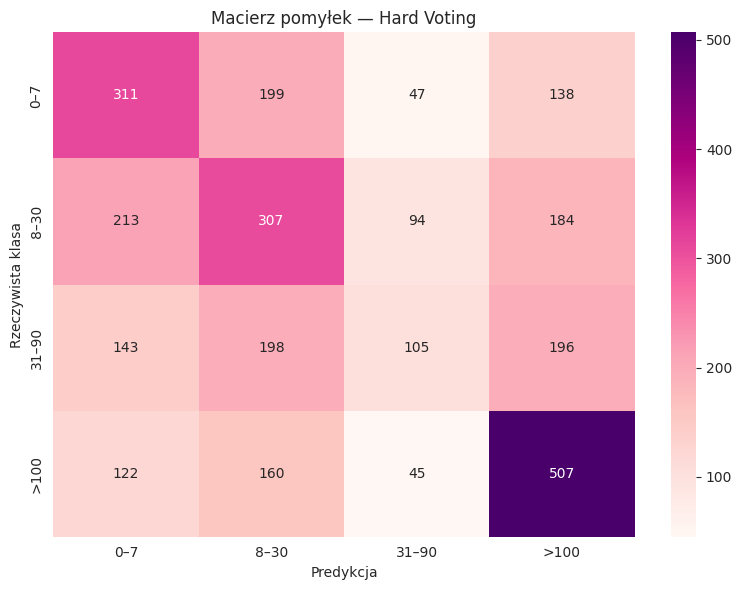

In [4]:
svm_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(svm_model))])
knn_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(knn_model))])
nn_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(nn_model))])

# SVM, KNN i MLP wymagaja skalowania, RF nie
estimators = [
    ('rf', clone(rf_model)),
    ('svm', svm_pipe),
    ('knn', knn_pipe),
    ('nn', nn_pipe),
]

hard_voting = VotingClassifier(estimators=estimators, voting='hard')
hard_voting.fit(X_train, y_train)

y_pred_hard = hard_voting.predict(X_test)

acc_hard = accuracy_score(y_test, y_pred_hard)
f1_hard = f1_score(y_test, y_pred_hard, average='macro')

print('Hard Voting')
print(classification_report(y_test, y_pred_hard, target_names=CLASS_NAMES))
print(f'Accuracy: {acc_hard:.4f}')
print(f'F1 macro: {f1_hard:.4f}')

cm_hard = confusion_matrix(y_test, y_pred_hard, labels=CLASS_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='RdPu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Macierz pomyłek — Hard Voting')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.show()

### Weighted Voting